<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/rede_SOM_aplicada_a_agrupamento_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=c2febae14564d6dd976ffee5eccb2412dc52a7872d6fc0fd956e89923849ef45
  Stored in directory: /root/.cache/pip/wheels/0f/8c/a4/5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom


# Após importação, utilizar o comando:

from minisom import MiniSom

Uma rede SOM pode ser gerada a partir do comando abaixo:

som = MiniSom(10, 10, 5, sigma=0.3, learning_rate=0.5)

Nesse exemplo, estamos criando uma rede SOM com 100 neurônios (grid 10x10), cada exemplo está em um espaço de atributos com 5 dimensões, a taxa de aprendizagem inicial é configurada em 0,5 e o sigma define a abertura da gaussiana (vizinhança da rede)

O mapa pode ser iniciado utilizando outros parâmetros opcionais:

Minisom(): def __init__(self, x, y, input_len, sigma=1.0, learning_rate=0.5, decay_function=asymptotic_decay, neighborhood_function='gaussian', topology='rectangular', activation_distance='euclidean', random_seed=None):

# Base de dados das Flores de Íris

In [2]:
from minisom import MiniSom
import sklearn.datasets
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [3]:
dados = sklearn.datasets.load_iris()
df = pd.DataFrame(dados.data, columns = dados.feature_names)
df['label'] = [dados.target_names[i] for i in dados.target]
# sns.pairplot(df, hue = 'label')
print(df)

     sepal length (cm)  sepal width (cm)  ...  petal width (cm)      label
0                  5.1               3.5  ...               0.2     setosa
1                  4.9               3.0  ...               0.2     setosa
2                  4.7               3.2  ...               0.2     setosa
3                  4.6               3.1  ...               0.2     setosa
4                  5.0               3.6  ...               0.2     setosa
..                 ...               ...  ...               ...        ...
145                6.7               3.0  ...               2.3  virginica
146                6.3               2.5  ...               1.9  virginica
147                6.5               3.0  ...               2.0  virginica
148                6.2               3.4  ...               2.3  virginica
149                5.9               3.0  ...               1.8  virginica

[150 rows x 5 columns]


In [4]:
x = df.drop(['label'], axis=1)

# Normalizando os dados (MinMax)
# normalizador = MinMaxScaler()
# x_norm = pd.DataFrame(normalizador.fit_transform(x), columns=x.columns)
labels = df.label.unique()

df['label'].replace(df['label'].unique(), [0,1,2], inplace=True)
target = df['label'].values
print(df)

     sepal length (cm)  sepal width (cm)  ...  petal width (cm)  label
0                  5.1               3.5  ...               0.2      0
1                  4.9               3.0  ...               0.2      0
2                  4.7               3.2  ...               0.2      0
3                  4.6               3.1  ...               0.2      0
4                  5.0               3.6  ...               0.2      0
..                 ...               ...  ...               ...    ...
145                6.7               3.0  ...               2.3      2
146                6.3               2.5  ...               1.9      2
147                6.5               3.0  ...               2.0      2
148                6.2               3.4  ...               2.3      2
149                5.9               3.0  ...               1.8      2

[150 rows x 5 columns]


/tmp/ipython-input-284874101.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'].replace(df['label'].unique(), [0,1,2], inplace=True)


Text(0.5, 1.0, 'Mapa de Correlação entre Atributos')

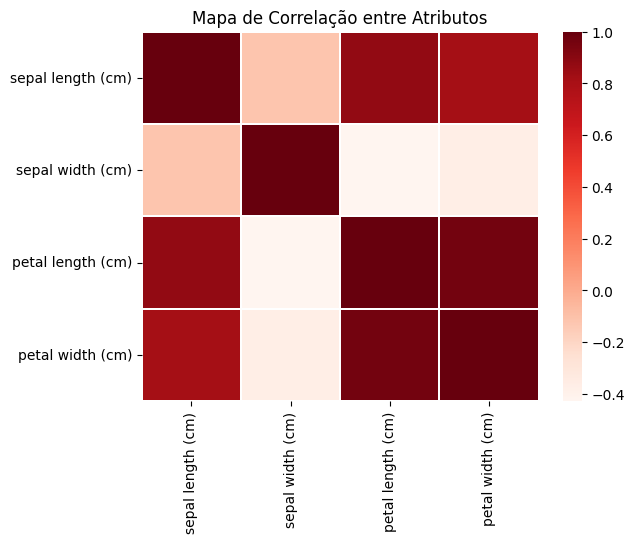

In [5]:
sns.heatmap(x.astype(float).corr(), linewidths = 0.1, linecolor = 'white', cmap ="Reds")
plt.title('Mapa de Correlação entre Atributos')

# Modelo 01 (7x5)

In [6]:
sigma = 5
eta = 0.1
epocas = 500
random_seed = 1

neighborhood_function = 'gaussian'
topology = 'rectangular'
neuD1 = 7 # numero de neurônios (dimensão 01 - linhas)
neuD2 = 5 # numero de neurônios (dimensão 02 - colunas)

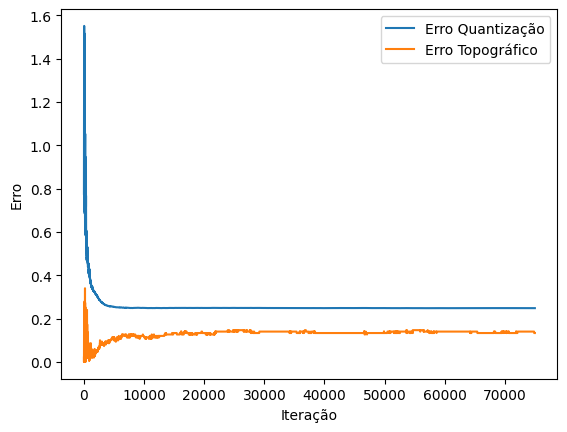

In [8]:
som = MiniSom(neuD1, neuD2, x.shape[1],
              sigma= sigma,
              neighborhood_function=neighborhood_function,
              random_seed=random_seed)

som.random_weights_init(x.values)
som.train_random(x.values, epocas)

q_error = []
t_error = []

for i in range(epocas*len(x.values)):
  rand_i = np.random.randint(len(x.values))
  som.update(x.values[rand_i], som.winner(x.values[rand_i]), i, epocas)
  q_error.append(som.quantization_error(x.values))
  t_error.append(som.topographic_error(x.values))

plt.plot(np.arange(epocas*len(x.values)), q_error, label='Erro Quantização')
plt.plot(np.arange(epocas*len(x.values)), t_error, label='Erro Topográfico')
plt.ylabel('Erro')
plt.xlabel('Iteração')
plt.legend()
plt.show()

In [9]:
# Erro de Quantização

som.quantization_error(x.values)

np.float64(0.24816295711855438)

In [10]:
# Erro Topográfico

som.topographic_error(x.values)

np.float64(0.13333333333333333)

# U-Matrix

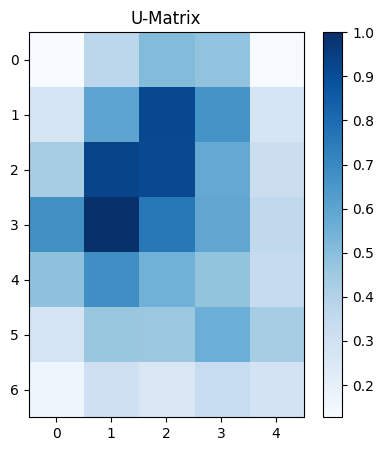

In [11]:
figure (figsize=(5,5), dpi=100)
plt.imshow(som.distance_map(), cmap="Blues")
plt.title('U-Matrix')
plt.colorbar()
plt.show()

# HitMap

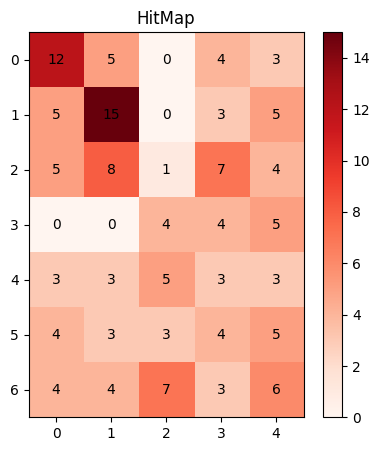

In [13]:
hits = som.activation_response(x.values).astype(int)
# hits = hits.T[::-1]
figure(figsize=(5,5), dpi=100)
plt.imshow(hits, cmap='Reds')
plt.colorbar()
for (i, j), value in np.ndenumerate(hits):
  plt.text(j, i, value, horizontalalignment='center', verticalalignment='center')
plt.title('HitMap')
plt.show()

# Heat Maps

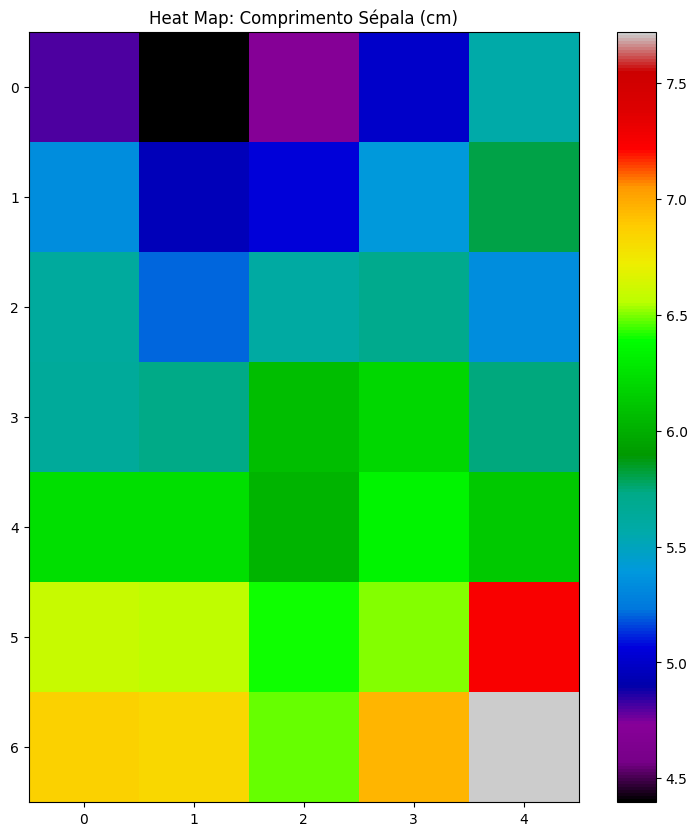

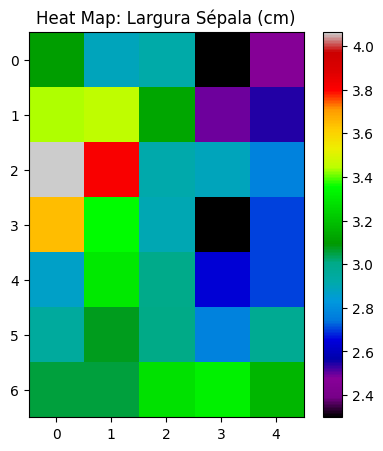

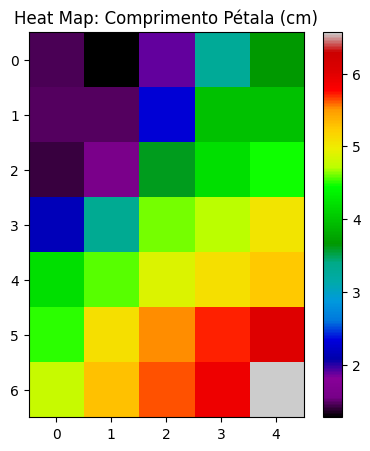

In [14]:
weights = som.get_weights()
figure(figsize=(10,10), dpi=100)
plt.title('Heat Map: Comprimento Sépala (cm)')
plt.imshow(weights[:,:,0], cmap='nipy_spectral')
plt.colorbar()
plt.show()

figure (figsize=(5,5), dpi=100)
plt.title('Heat Map: Largura Sépala (cm)')
plt.imshow(weights[:,:,1], cmap='nipy_spectral')
plt.colorbar()
plt.show()

figure (figsize=(5,5), dpi=100)
plt.title('Heat Map: Comprimento Pétala (cm)')
plt.imshow(weights[:,:,2], cmap='nipy_spectral')
plt.colorbar()
plt.show()

# Mapa de Distribuição das Classes

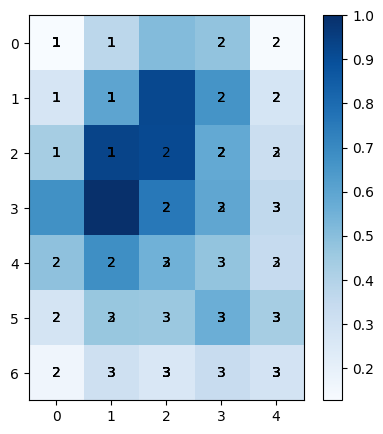

In [15]:
figure (figsize=(5,5), dpi=100)
plt.imshow(som.distance_map(), cmap='Blues')
plt.colorbar()

# Plotagem das classes associadas a cada neurônio
for idx, xx in enumerate(x.values):
  w = som.winner(xx) # Encontrando o vencedor para o padrão x
  plt.text(w[1], w[0], target[idx]+1, horizontalalignment='center', verticalalignment='center')

plt.show()

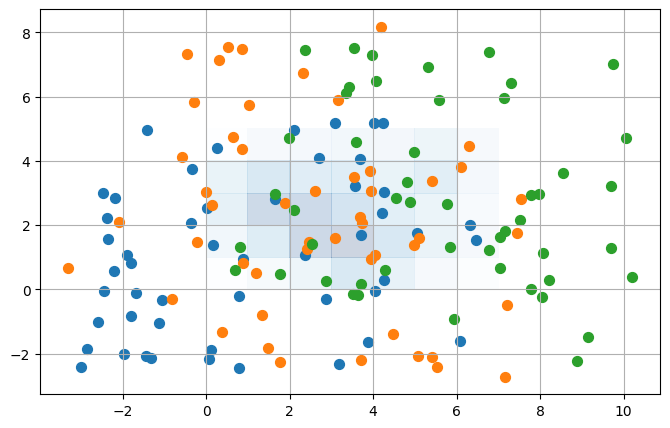

In [18]:
w_x, w_y = zip(*[som.winner(d) for d in x.values])
w_x = np.array(w_x)
w_y = np.array(w_y)

figure (figsize=(8,5), dpi=100)
plt.pcolor(som.distance_map().T, cmap='Blues', alpha=.2)
plt.colorbar

for c in np.unique(target):
  idx_target = target==c
  plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*8,
              w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*8,
              s=50, label=target[c])

plt.grid()
plt.show()

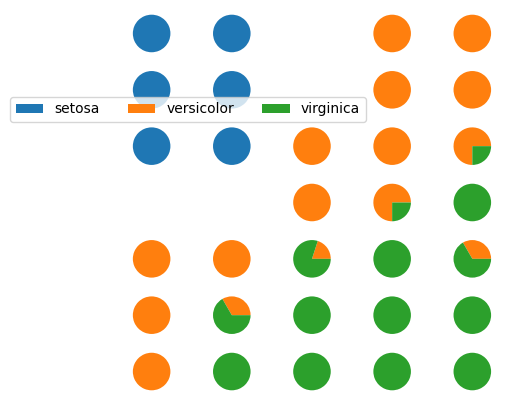

In [22]:
import matplotlib.gridspec as gridspec

labels_map = som.labels_map(x.values, [labels[t] for t in target])

fig = plt.figure(figsize=(5,5))
the_grid = gridspec.GridSpec(neuD1, neuD2, fig)
for position in labels_map.keys():
  label_fracs = [labels_map[position][l] for l in labels]
  if sum(label_fracs) > 0: # Check if there are any data points mapped to this position
    plt.subplot(the_grid[position[0],
                         position[1]], aspect=1)
    patches, text = plt.pie(label_fracs) # Add labels to the pie chart

plt.legend(patches, labels, bbox_to_anchor=(3.5, 6.5), ncol=3)
plt.show()

# Modelo 02 (30x20)

In [23]:
sigma = 10
eta = 0.1
epocas = 5000
random_seed = 1

neighborhood_function = 'gaussian'
topology = 'rectangular'
neuD1 = 30 # numero de neurônios (dimensão 01 - linhas)
neuD2 = 20 # numero de neurônios (dimensão 02 - colunas)

In [24]:
som = MiniSom(neuD1, neuD2, x.shape[1],
              sigma=sigma,
              learning_rate=eta,
              neighborhood_function=neighborhood_function,
              random_seed=random_seed)

som.random_weights_init(x.values)
som.train_random(x.values, epocas)

In [25]:
# Erro de Quantização

som.quantization_error(x.values)

np.float64(0.2690198488027468)

In [26]:
# Erro Topográfico

som.topographic_error(x.values)

np.float64(0.02)

# U-Matrix

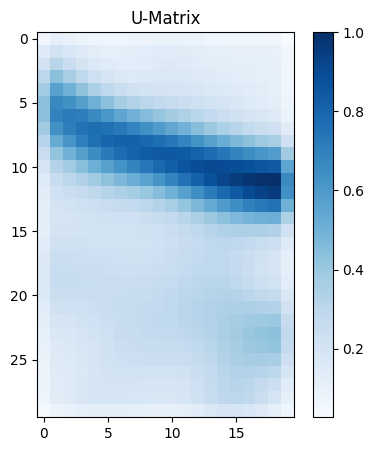

In [27]:
figure (figsize=(5,5), dpi=100)
plt.imshow(som.distance_map(), cmap="Blues")
plt.title('U-Matrix')
plt.colorbar()
plt.show()

# Hitmap

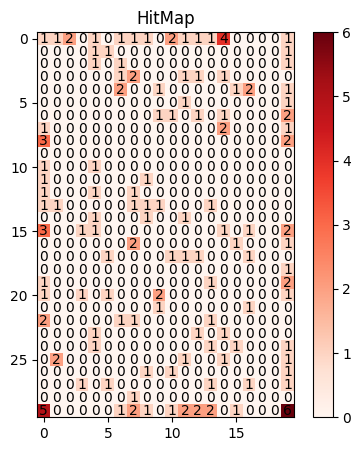

In [28]:
hits = som.activation_response(x.values).astype(int)
# hits = hits.T[::-1]
figure(figsize=(5,5), dpi=100)
plt.imshow(hits, cmap='Reds')
plt.colorbar()

for (i, j), value in np.ndenumerate(hits):
  plt.text(j, i, value, horizontalalignment='center', verticalalignment='center')
plt.title('HitMap')
plt.show()

# Heat Maps

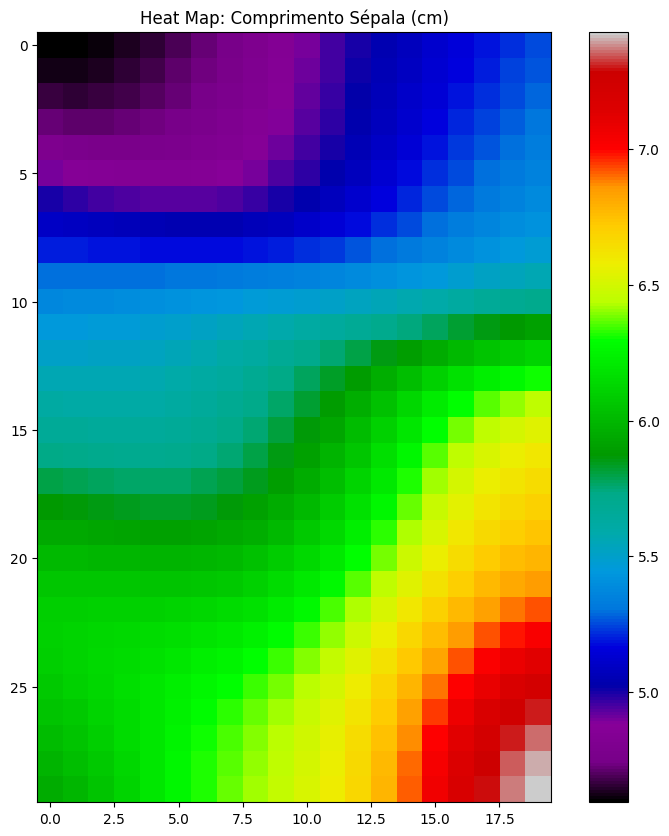

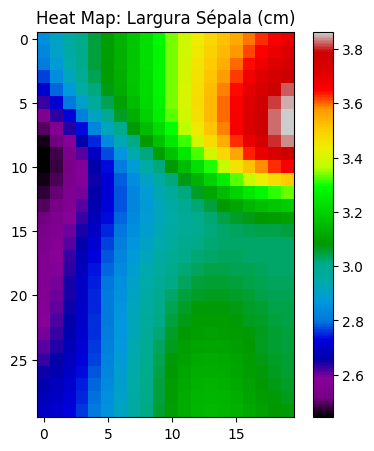

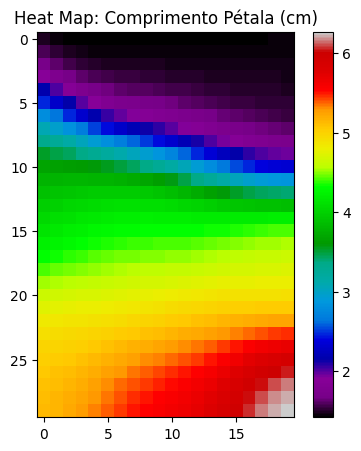

In [29]:
weights = som.get_weights()
figure(figsize=(10,10), dpi=100)
plt.title('Heat Map: Comprimento Sépala (cm)')
plt.imshow(weights[:,:,0], cmap='nipy_spectral')
plt.colorbar()
plt.show()

figure (figsize=(5,5), dpi=100)
plt.title('Heat Map: Largura Sépala (cm)')
plt.imshow(weights[:,:,1], cmap='nipy_spectral')
plt.colorbar()
plt.show()

figure (figsize=(5,5), dpi=100)
plt.title('Heat Map: Comprimento Pétala (cm)')
plt.imshow(weights[:,:,2], cmap='nipy_spectral')
plt.colorbar()
plt.show()

# Mapa de Distribuição das Classes

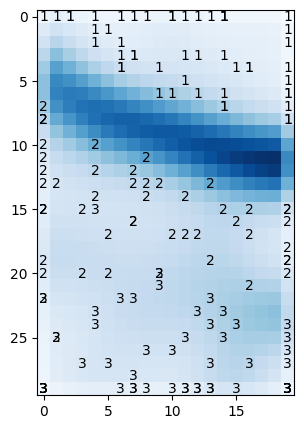

In [30]:
figure (figsize=(5,5), dpi=100)
plt.imshow(som.distance_map(), cmap='Blues')
plt.colorbar

# Plotagem das classes associadas a cada neurônio
for idx, xx in enumerate(x.values):
  w = som.winner(xx) # Encontrando o vencedor para o padrão x
  plt.text(w[1], w[0], target[idx]+1, horizontalalignment='center', verticalalignment='center')

plt.show()

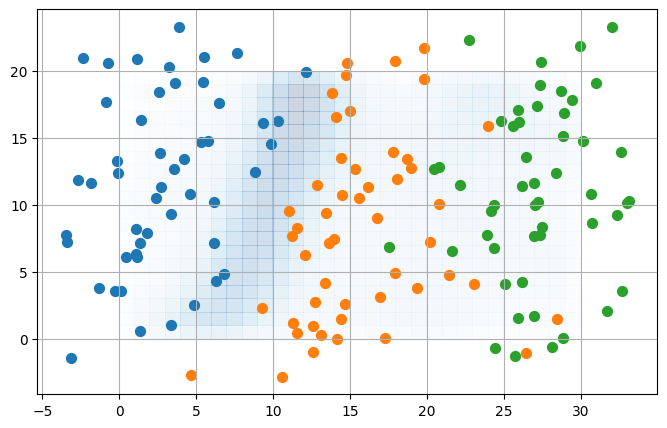

In [31]:
w_x, w_y = zip(*[som.winner(d) for d in x.values])
w_x = np.array(w_x)
w_y = np.array(w_y)

figure (figsize=(8,5), dpi=100)
plt.pcolor(som.distance_map().T, cmap='Blues', alpha=.2)
plt.colorbar

for c in np.unique(target):
  idx_target = target==c
  plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*8,
              w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*8,
              s=50, label=target[c])

plt.grid()
plt.show()

# Modelo 03 (30x20)

## Com Vizinhança Inadequada

In [32]:
sigma = 1
eta = 0.1
epocas = 5000
random_seed = 1

neighborhood_function='gaussian'
topology='rectangular'
neuD1 = 30 # numero de neurônios (dimensão 01 - linhas)
neuD2 = 20 # numero de neurônios (dimensão 02 - colunas)

som = MiniSom(neuD1, neuD2, x.shape[1],
              sigma=sigma,
              learning_rate=eta,
              neighborhood_function=neighborhood_function,
              random_seed=random_seed)

som.random_weights_init(x.values)
som.train_random(x.values, epocas)

In [33]:
# Erro de Quantização

som.quantization_error(x.values)

np.float64(0.06921232341885424)

In [34]:
# Erro Topográfico

som.topographic_error(x.values)

np.float64(0.8266666666666667)

# U-Matrix

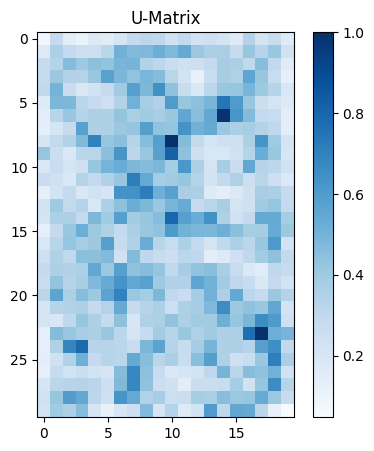

In [35]:
figure (figsize=(5,5), dpi=100)
plt.imshow(som.distance_map(), cmap="Blues")
plt.title('U-Matrix')
plt.colorbar()
plt.show()

# HitMap

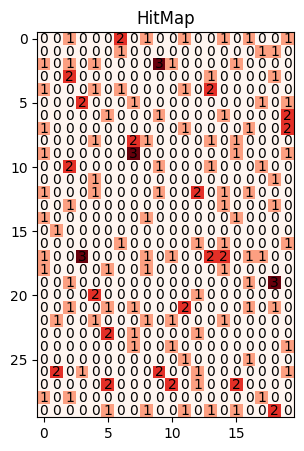

In [36]:
hits = som.activation_response(x.values).astype(int)
# hits = hits.T[::-1]
figure(figsize=(5,5), dpi=100)
plt.imshow(hits, cmap='Reds')
plt.colorbar

for (i, j), value in np.ndenumerate(hits):
  plt.text(j, i, value, horizontalalignment='center', verticalalignment='center')
plt.title('HitMap')
plt.show()

# Heat Maps

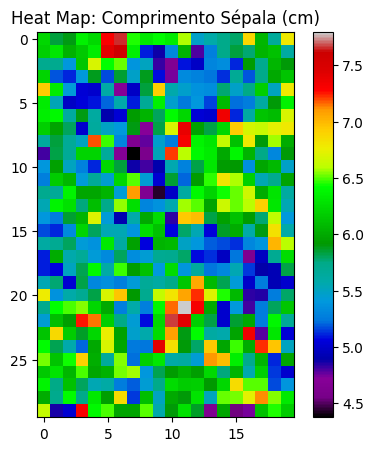

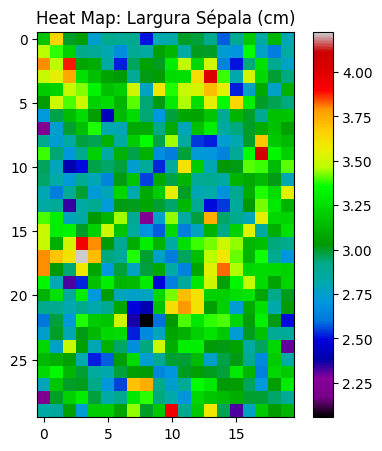

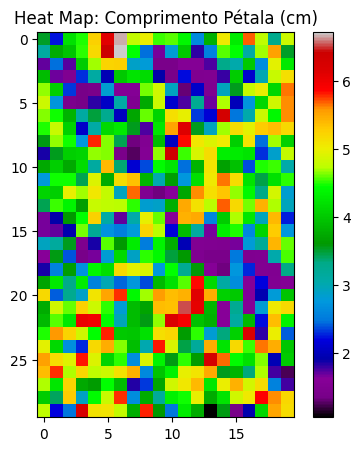

In [37]:
weights = som.get_weights()
figure (figsize=(5,5), dpi=100)
plt.title('Heat Map: Comprimento Sépala (cm)')
plt.imshow(weights[:,:,0], cmap='nipy_spectral')
plt.colorbar()
plt.show()

figure (figsize=(5,5), dpi=100)
plt.title('Heat Map: Largura Sépala (cm)')
plt.imshow(weights[:,:,1], cmap='nipy_spectral')
plt.colorbar()
plt.show()

figure (figsize=(5,5), dpi=100)
plt.title('Heat Map: Comprimento Pétala (cm)')
plt.imshow(weights[:,:,2], cmap='nipy_spectral')
plt.colorbar()
plt.show()

# Mapa de Distribuição das Classes

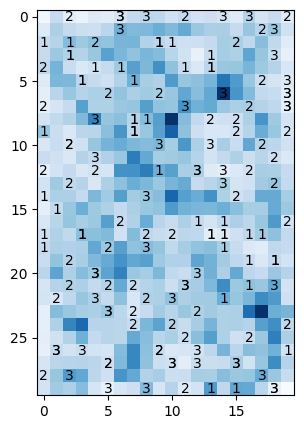

In [38]:
figure (figsize=(5,5), dpi=100)
plt.imshow(som.distance_map(), cmap='Blues')
plt.colorbar

# Plotagem das classes associadas a cada neurônio
for idx, xx in enumerate(x.values):
  w = som.winner(xx) # Encontrando o vencedor para o padrão x
  plt.text(w[1], w[0], target[idx]+1, horizontalalignment='center', verticalalignment='center')


plt.show()

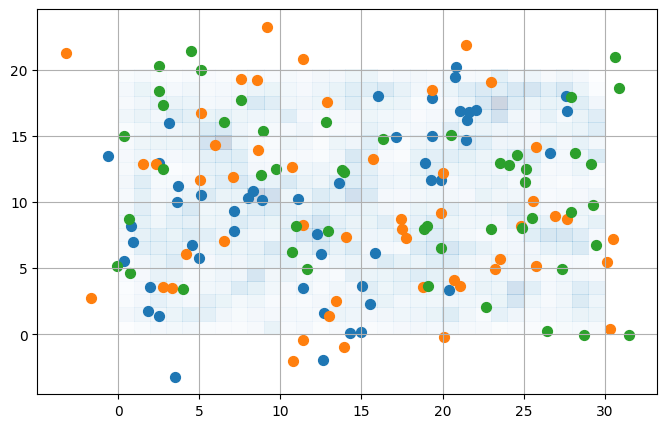

In [39]:
w_x, w_y = zip(*[som.winner(d) for d in x.values])
w_x = np.array(w_x)
w_y = np.array(w_y)

figure (figsize=(8,5), dpi=100)
plt.pcolor(som.distance_map().T, cmap='Blues', alpha=.2)
plt.colorbar

for c in np.unique(target):
  idx_target = target==c
  plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*8,
              w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*8,
              s=50, label=target[c])

plt.grid()
plt.show()